<a href="https://colab.research.google.com/github/ShreyasJV/ml-project/blob/main/Network_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting a 1D function with  neural network

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Defining a network object
In order to streamline this a little, we define an object Network which is initalised with a given layer structure of random weights.

In [ ]:
# @title
class Network:
    def __init__(self, layers, activations = None, weights = None, biases = None):
        """
        parameters:

        - layers: np.array shape (numlayers,) ; e.g. [3,4,6,2] gives the number of neurons in each layer, including input and output
        - activations: list or str ; e.g. ("sigmoid","reLU","sigmoid","linear") will give these activations across each layer. customised below.
        - weights: np.array shape (hard to write) ; list of matrices eg [W1,W2,W3] where eg on layers ~ [3,4,6,2] we have W1 is 4*3, W2 is 6*4, W3 is 2*6.
        - biases: np.array shape (hard to write) ; list of biases eg [B1,B2,B3] where eg on layers ~ [3,4,6,2] we have B1 is len=4, B2 is len=6, B3 is len=2
        """

        self.nLayers = len(layers)
        self.nNeurons = layers

        # Initialise activation function structures for each layer
        if activations == None:
            self.activations = ["sigmoid"]*(self.nLayers-1)
        elif type(activations) == list:
            if len(activations) != self.nLayers - 1:
                raise Exception("The length of your list of activations must match the number of layers!")
            self.activations = activations
        elif type(activations) == str:
            self.activations = [activations]*(self.nLayers-1) # The activation in the string is used across all layers

        # Determine correct shapes for weights and biases
        self.weightsShape = [(self.nNeurons[j+1], self.nNeurons[j]) for j in range(self.nLayers - 1)] #this is a list of what the rows and column numbers are for W at each layer eg [(4,3),(6,4),(2,6)]. note the consistency condition between entries.
        self.biasesShape = [(self.nNeurons[j+1],1) for j in range(self.nLayers - 1)] #list of shapes for biases eg [(4,1),(6,1),(2,1)]

        # Initialise weights
        if weights == None:
            self.weights = [np.random.uniform(low = -1.,
                                              high = 1.,
                                              size = [self.nNeurons[j+1],self.nNeurons[j]])
                            for j in range(self.nLayers-1)]
        elif [_wMat.shape for _wMat in weights] == self.weightsShape:
            self.weights = weights
        else:
            raise Exception("I hate your weights!") # bad shapes

        # Initialise biases
        if biases == None:
            self.biases = [np.random.uniform(low = -1.,
                                              high = 1.,
                                              size = [self.nNeurons[j+1],1])
                            for j in range(self.nLayers-1)]
        elif [_bVec.shape for _bVec in biases] == self.biasesShape:
            self.biases = biases
        else:
            raise Exception("I hate your biases!") # bad shapes

        self.backpropagating = False # initialise this to false so that we can flip it to true later.

    def ActivationFunction(self, yInput, label = None, Q_return_df = False):
        if label == None:
            label = "sigmoid"
        if label == "sigmoid":
            if Q_return_df == True: # useful for backprop
                return 1/(1+np.exp(-yInput)), np.exp(-yInput)/(1+np.exp(-yInput))**2
            else:
                return 1/(1+np.exp(-yInput))
        if label == "step":
            return (yInput >= 0)
        if label == "reLU":
            if Q_return_df == True:
                return (yInput > 0) * yInput, (yInput>0)
            else:
                return (yInput >= 0) * yInput

    def ForwardStep(self, layerIndex, yInput): #performs a single step.
        yOut = np.dot(self.weights[layerIndex - 1],yInput) + self.biases[layerIndex - 1] # this is not taking advantage of batch processing. fix it to take in a whole batch as input.
        if self.backpropagating == True:
            zOut, dfOut = self.ActivationFunction(yOut, self.activations[layerIndex - 1], Q_return_df = True)
            return zOut, dfOut
        else:
            zOut = self.ActivationFunction(yOut, self.activations[layerIndex - 1])
            return zOut

    def NetworkPass(self, yInput):
        yj = yInput
        if self.backpropagating == True:
            self.yi_layers[0] = yj
        for layerIndex in range(self.nLayers - 1):
            if self.backpropagating == True:
                yj, dfj = self.ForwardStep(layerIndex + 1, yj)
                self.yi_layers[layerIndex + 1] = yj
                self.dfi_layers[layerIndex] = dfj
            else:
                yj = self.ForwardStep(layerIndex+1,yj)
        return yj

    def BackPropagate(self, yBatch, yTarget):
        self.backpropagating = True

        batchSize = yBatch.shape[-1]

        self.yi_layers = [np.zeros([batchSize, self.nNeurons[j]])
                          for j in range(self.nLayers)]
        self.dfi_layers = [np.zeros([batchSize, self.nNeurons[j+1]])
                           for j in range(self.nLayers-1)]
        self.dwi_layers = [np.zeros([self.nNeurons[j+1], self.nNeurons[j]])
                            for j in range(self.nLayers-1)]
        self.dbi_layers = [np.zeros([self.nNeurons[j+1],1])
                            for j in range(self.nLayers-1)]

        yOut = self.NetworkPass(yBatch)
        delta = (self.yi_layers[-1] - yTarget)*self.dfi_layers[-1]
        self.dwi_layers[-1] = np.dot(delta,np.transpose(self.yi_layers[-2]))/batchSize
        self.dbi_layers[-1] = delta.sum(0)/batchSize
        for j in range(self.nLayers - 2):
            delta = np.dot(np.transpose(self.weights[-1-j]), delta)*self.dfi_layers[-2-j]
            self.dwi_layers[-2-j] = np.dot(delta, np.transpose(self.yi_layers[-3-j]))/batchSize
            self.dbi_layers = delta.sum(0)/batchSize
        return yOut

    def UpdateWeights(self, eta = 0.1):
        for j in range(self.nLayers-1):
            self.weights[j] -= eta*self.dwi_layers[j]
            self.biases[j] -= eta*self.dbi_layers[j]

    def TrainNet(self, yBatch, yTarget, eta = 0.0001): # one full training batch
        batchSize = yBatch.shape[-1]
        yOutput = self.BackPropagate(yBatch, yTarget)
        self.UpdateWeights(eta)
        cost=((yTarget-yOutput)**2).sum()/batchSize
        return(cost)

In [ ]:
# @title
a = Network([1,500,200,1],activations='sigmoid')
batchSize = 1000
sigma = 0.6
nEpochs = 500
cost = np.zeros(3*nEpochs)

_fig1, _axs1 = plt.subplots(nrows=10, figsize = (5,2*nEpochs//10))
for j in range(3):
    for i in tqdm(range(nEpochs)): # tqdm gives a progress bar
        yInput = np.zeros([1,batchSize])
        yInput += sorted(np.random.uniform(low=-2,high=2,size=batchSize))
        yTarget = np.exp(-(yInput**2)/(2*sigma**2)) #we now have our in-out training data for the curve exp(-x^2/ 2 s^2)
        cost[i] = a.TrainNet(yInput, yTarget, eta = 1*2**(-j))

        # print([np.sum((b-_w[j])**2,axis=all) for j, b in enumerate(a.weights)])
        if (j*nEpochs+i)%(3*nEpochs//10) == 0:
            _axs1[(j*nEpochs+i)//(3*nEpochs//10)].plot(yInput[0],a.yi_layers[-1][0],color='b')
            _axs1[(j*nEpochs+i)//(3*nEpochs//10)].plot(yInput[0],yTarget[0],color='r')
            _axs1[(j*nEpochs+i)//(3*nEpochs//10)].set_ylabel("E%i"%i)
plt.show()

NameError: name 'Network' is not defined

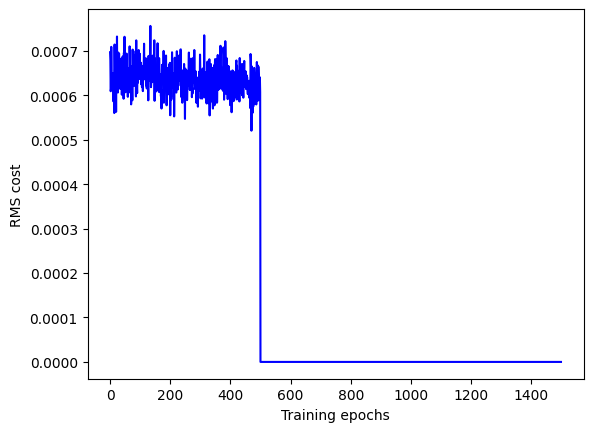

In [ ]:
# @title
_fig2, _axs2 = plt.subplots()
_axs2.plot(range(3*nEpochs),cost,'b')
_axs2.set_xlabel("Training epochs")
_axs2.set_ylabel("RMS cost")
plt.show()